# 📊 Análise de Série Temporal de Vendas

## 📌 Visão Geral
Este projeto analisa uma **série temporal mensal de vendas** simuladas, abrangendo o período de **jan/2021 a dez/2024** (48 observações).

Os dados foram construídos para refletir padrões realistas de negócio, incluindo **tendência de crescimento**, **sazonalidade anual** e **variações aleatórias**.

---

## 🎯 Objetivo
- Compreender o comportamento das vendas ao longo do tempo  
- Identificar padrões de tendência e sazonalidade  
- Avaliar modelos preditivos  
- Gerar previsões para períodos futuros  

---

## ⚙️ Características da Série
- **Frequência:** Mensal  
- **Período:** 2021–2024  
- **Variável:** Vendas  

---

## 🚀 Abordagem
1. Visualização da série  
2. Identificação de padrões  
3. Modelagem (ARIMA, Holt-Winters, etc.)  
4. Comparação de desempenho  
5. Previsão de vendas  

---

> ⚠️ Dados simulados, porém estruturados para representar cenários reais de análise de demanda.

# 1. Instalando as Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid' ] = True
plt.rcParams['grid.alpha'] = 0.3

print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


# 2. Criação dos Dados Fictícios

Vamos simular uma demanda que possui três componentes típicos de séries reais:

- Tendência: a demanda cresce gradualmente ao longo do tempo (ex: empresa crescendo)
- Sazonalidade: picos em determinados meses (ex: manutenções programadas no meio do ano)
- Ruído: variações aleatórias do dia a dia


In [ ]:
np.random.seed(42)

# 48 meses (Jan/2021 a Dez/2024)
datas = pd.date_range(start="2021-01-01", periods=48, freq="MS")
t = np.arange(len(datas))

# Tendência (crescimento ao longo do tempo)
tendencia = 200 + 2 * t

# Sazonalidade anual (base mensal → período = 12)
sazonalidade_anual = 30 * np.sin(2 * np.pi * t / 12)

# Ruído aleatório
ruido = np.random.normal(0, 10, len(datas))

# Vendas finais
vendas = tendencia + sazonalidade_anual + ruido
vendas = np.round(vendas).astype(int)

# Evitar valores negativos
vendas = np.clip(vendas, 0, None)

# DataFrame final
df = pd.DataFrame({
    "data": datas,
    "vendas": vendas
})

df = df.set_index("data")

print(f'Período: {df.index.min().strftime("%b/%Y")} até {df.index.max().strftime("%b/%Y")}')
print(f'Total de observações: {len(df)}')

df.head(12)

Período: Jan/2021 até Dec/2024
Total de observações: 48


,vendas
data,
2021-01-01,205
2021-02-01,216
2021-03-01,236
2021-04-01,251
2021-05-01,232
2021-06-01,223
2021-07-01,228
2021-08-01,207
2021-09-01,185


# 3. Análise Exploratória

# 3.1 Série Completa

##  Série Temporal Completa

A visualização da série mostra a evolução das vendas mensais ao longo do tempo.

- Há uma **tendência de crescimento** consistente  
- Observa-se um **padrão sazonal recorrente**  
- Existe **variabilidade** devido a ruídos  

Essa análise inicial confirma que os dados possuem estrutura adequada para modelagem de séries temporais.


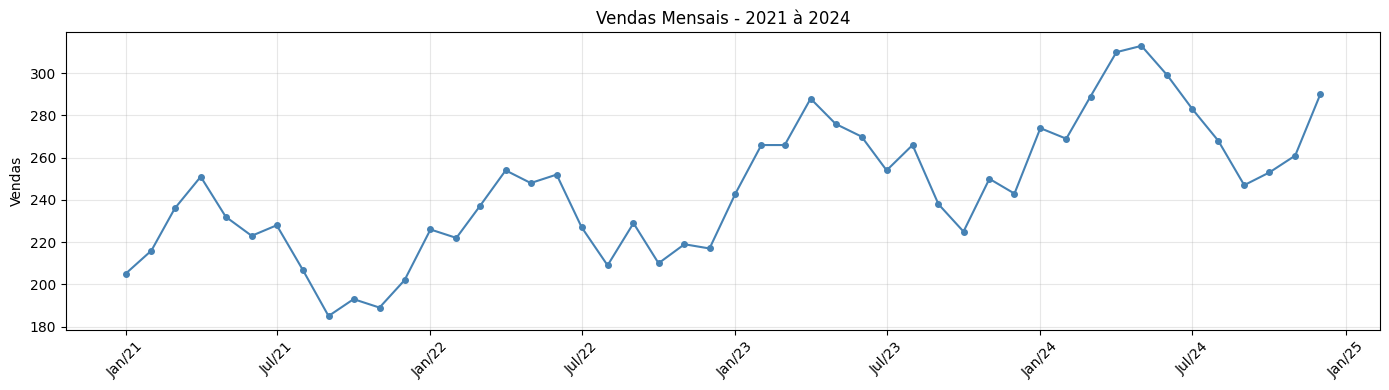

In [ ]:
fig, ax = plt.subplots()
ax.plot(df.index, df['vendas'], marker='o', markersize=4, linewidth=1.5, color='steelblue')
ax.set_title('Vendas Mensais - 2021 à 2024')
ax.set_ylabel('Vendas')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##  Suavização com Média Móvel

Para reduzir a volatilidade e destacar o padrão da série, foi aplicada uma **média móvel de 3 períodos**.

- A suavização evidencia melhor a **tendência**  
- Reduz o impacto de oscilações pontuais  
- Facilita a visualização do comportamento geral  

A média móvel confirma o crescimento ao longo do tempo e torna a sazonalidade mais evidente.

In [ ]:
dados = df.copy()

dados['Vendas_mm3'] = dados['vendas'].rolling(3).mean()
dados['Vendas_mm6'] = dados['vendas'].rolling(6).mean()

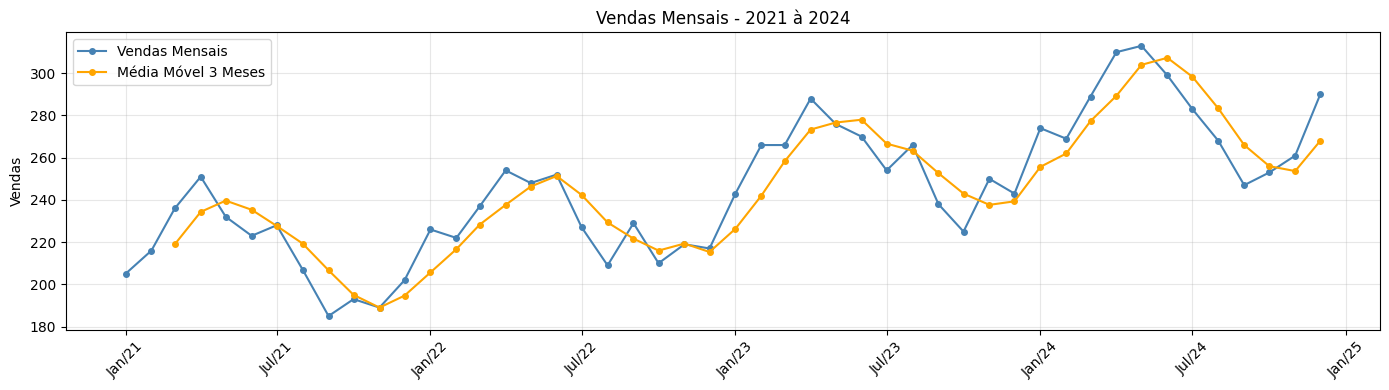

In [ ]:
fig, ax = plt.subplots()
ax.plot(df.index, df['vendas'], marker='o', markersize=4, linewidth=1.5, color='steelblue', label='Vendas Mensais')
ax.plot(dados.index, dados['Vendas_mm3'], marker='o', markersize=4, linewidth=1.5, color='orange', label='Média Móvel 3 Meses')
ax.set_title('Vendas Mensais - 2021 à 2024')
ax.set_ylabel('Vendas')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 3.2 Estatísticas Descritivas

##  Estatísticas Descritivas

A distribuição das vendas apresenta comportamento aproximadamente **normal**, com leve dispersão ao redor da média.


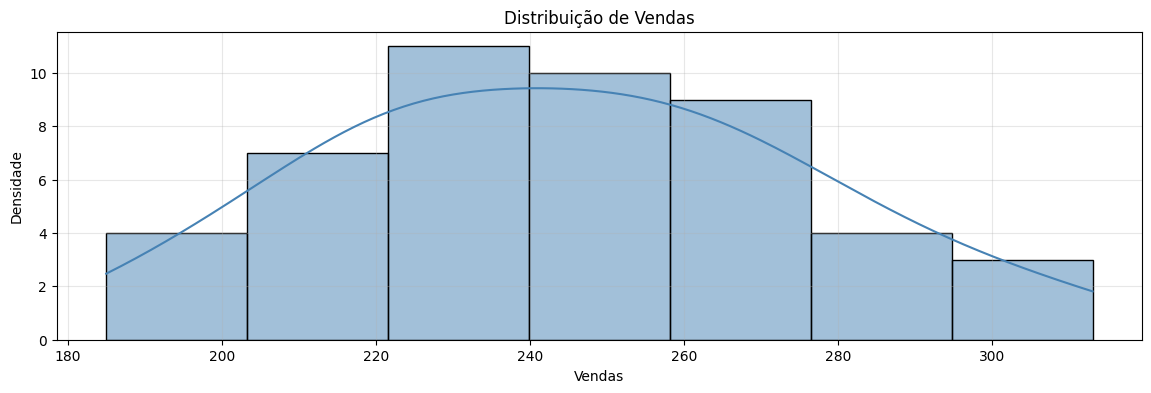

In [ ]:
sns.histplot(df['vendas'], kde=True, color='steelblue')
plt.title('Distribuição de Vendas')
plt.xlabel('Vendas')
plt.ylabel('Densidade')
plt.show()

In [ ]:
print(' === Estatísticas Descritivas ===')
print(df['vendas'].describe().round(2))

 === Estatísticas Descritivas ===
count     48.00
mean     244.96
std       31.50
min      185.00
25%      222.75
50%      245.00
75%      266.50
max      313.00
Name: vendas, dtype: float64


###  Principais métricas:
- **Média:** ~245 vendas  
- **Mediana:** ~246 vendas  
- **Mínimo:** 185 vendas  
- **Máximo:** 313 vendas  
- **Desvio padrão:** ~31  

###  Interpretação:
- A proximidade entre **média e mediana** indica baixa assimetria  
- A dispersão é moderada, refletindo variações naturais ao longo do tempo  
- Não há presença evidente de outliers extremos  

No geral, os dados mostram um comportamento estável e consistente, adequado para modelagem de séries temporais.

## 3.3 Sazonalidade - Média por Mês do Ano

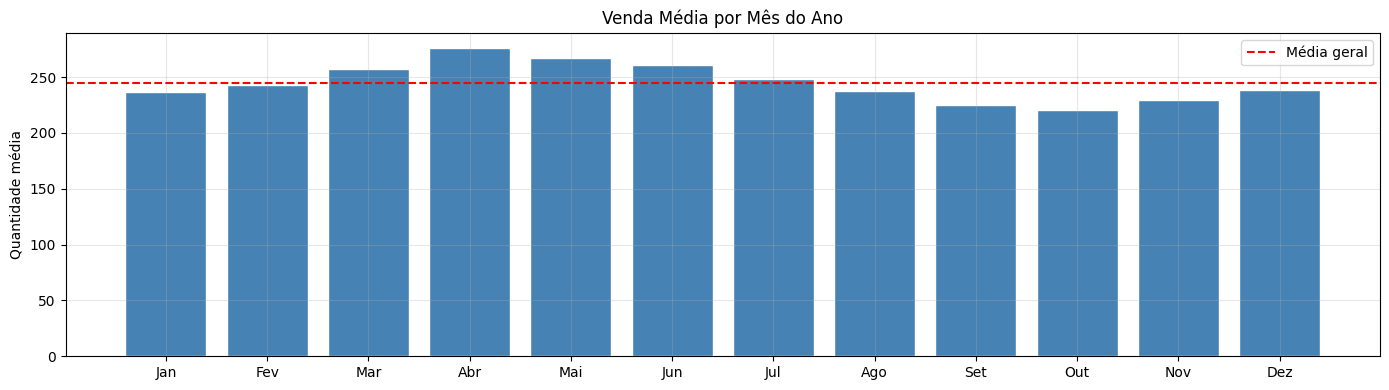

In [ ]:
nomes_meses = ['Jan','Fev','Mar','Abr', 'Mai' ,'Jun' , 'Jul' ,'Ago' ,'Set' , 'Out' ,'Nov', 'Dez' ]
media_por_mes = df.groupby(df.index.month)['vendas'].mean()

fig, ax = plt.subplots()
ax.bar(nomes_meses, media_por_mes.values, color='steelblue', edgecolor='white')
ax.axhline(df['vendas'].mean(), color='red', linestyle='--', label='Média geral')
ax.set_title('Venda Média por Mês do Ano')
ax.set_ylabel('Quantidade média')
ax.legend()
plt.tight_layout()
plt.show()

A média de vendas por mês indica um padrão sazonal ao longo do ano.

- **Mar–Jun:** acima da média (pico em abr/mai)  
- **Set–Out:** menores valores  
- Oscilações próximas da média geral (~245)

### 📌 Interpretação
Há **sazonalidade anual clara**, indicando variações recorrentes de demanda. Modelos que consideram esse padrão tendem a ter melhor desempenho.

# 3.4 Tendência - Média por Ano

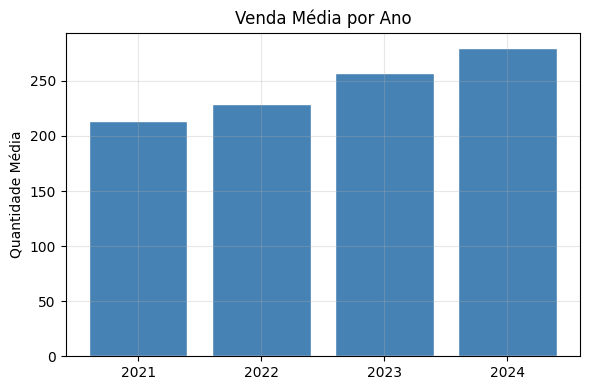

Crescimento ano a ano: 
2022 - 15.25 (7.13%)
2023 - 27.92 (12.18%)
2024 - 22.58 (8.78%)


In [ ]:
media_por_ano = df.groupby(df.index.year)['vendas'].mean()

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(media_por_ano.index.astype(str), media_por_ano.values, color='steelblue', edgecolor='white')
ax.set_title('Venda Média por Ano')
ax.set_ylabel('Quantidade Média')
plt.tight_layout()
plt.show()

print('Crescimento ano a ano: ')
for i in range(1, len(media_por_ano)):
  delta = media_por_ano.iloc[i] - media_por_ano.iloc[i-1]
  pct = delta / media_por_ano.iloc[i-1] * 100
  print(f'{media_por_ano.index[i]} - {delta:.2f} ({pct:.2f}%)')



A média anual de vendas apresenta crescimento consistente ao longo do período.

- 2021 → 2024: aumento contínuo  
- Maior crescimento entre 2021 e 2023  
- Crescimento mais moderado em 2024  

### 📌 Interpretação
A série possui uma **tendência de alta clara**, indicando expansão das vendas ao longo do tempo.

## 3.5 Decomposição da Série
A decomposição separa automaticamente a série em três camadas:
- Trend (tendência): direção geral da série
- Seasonal (sazonalidade): padrão repetitivo
- Residual (resíduo): o que sobra depois de remover os dois anteriores - idealmente é só ruído

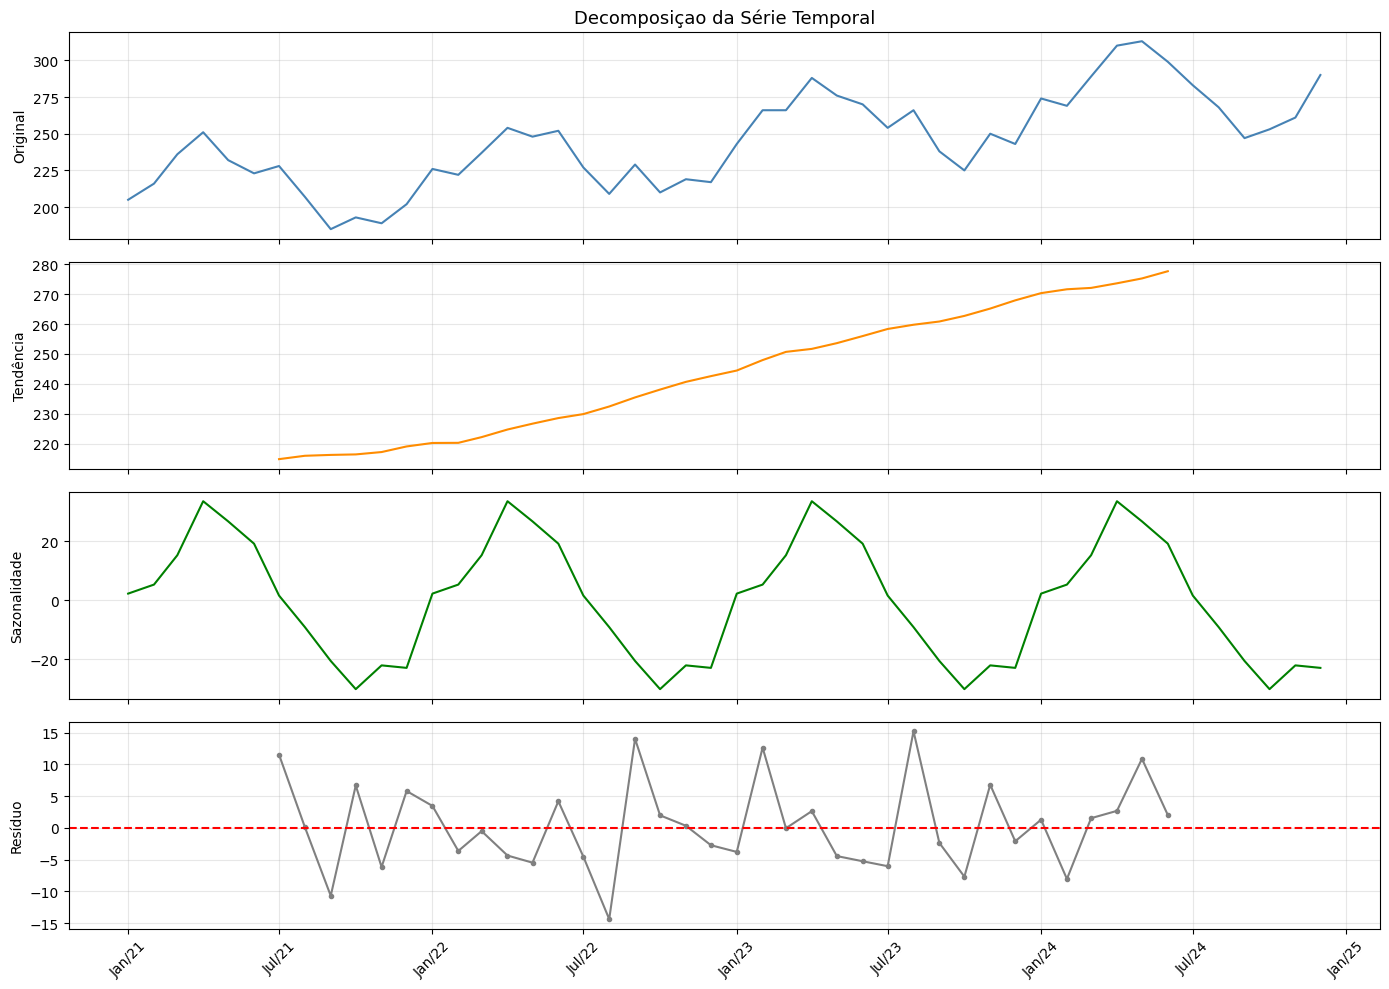

In [ ]:
decomposicao = seasonal_decompose(df['vendas'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['vendas' ], color='steelblue')
axes[0].set_ylabel('Original')
axes[0].set_title('Decomposiçao da Série Temporal', fontsize=13)

axes[1].plot(df.index, decomposicao.trend, color='darkorange')
axes[1].set_ylabel('Tendência')

axes[2].plot(df.index, decomposicao.seasonal, color='green' )
axes[2].set_ylabel('Sazonalidade')

axes[3].plot(df.index, decomposicao.resid, color='gray', marker='o', markersize=3)
axes[3].axhline(0, color='red', linestyle='--')
axes[3].set_ylabel('Resíduo')

for ax in axes:
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))

plt.xticks(rotation=45)
plt.tight_layout()
plt. show()

A decomposição separa a série em três componentes: tendência, sazonalidade e resíduo.

- **Tendência:** crescimento contínuo ao longo do tempo  
- **Sazonalidade:** padrão anual bem definido  
- **Resíduo:** variações aleatórias próximas de zero  

### 📌 Interpretação
A série apresenta estrutura clara, com **tendência e sazonalidade bem definidas**, sendo adequada para modelos como SARIMA ou Holt-Winters.

## 3.6 ACF e PACF

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

def estac(df):

  adf = adfuller(df)
  print(f'Valor-p do Teste ADF: {adf[1]:.4f}')
  if adf[1] > 0.05:
    print('Não rejeitar a Hipótese Nula: a série não é estacionária\n')
  else:
    print('Rejeitar a Hipótese Nula: a série é estacionária\n')

  kpss_saida = kpss(df)
  print(f'Valor-p do Teste KPSS: {kpss_saida[1]:.4f}')
  if kpss_saida[1] > 0.05:
    print('Não rejeitar a Hipótese Nula: a série é estacionária\n')
  else:
    print('Rejeitar a Hipótese Nula: a série não é estacionária\n')

In [ ]:
estac(df)

Valor-p do Teste ADF: 0.9950
Não rejeitar a Hipótese Nula: a série não é estacionária

Valor-p do Teste KPSS: 0.0105
Rejeitar a Hipótese Nula: a série não é estacionária



Os testes indicam que a série **não é estacionária**.

- **ADF:** não rejeita hipótese nula → série não estacionária  
- **KPSS:** rejeita hipótese nula → série não estacionária  

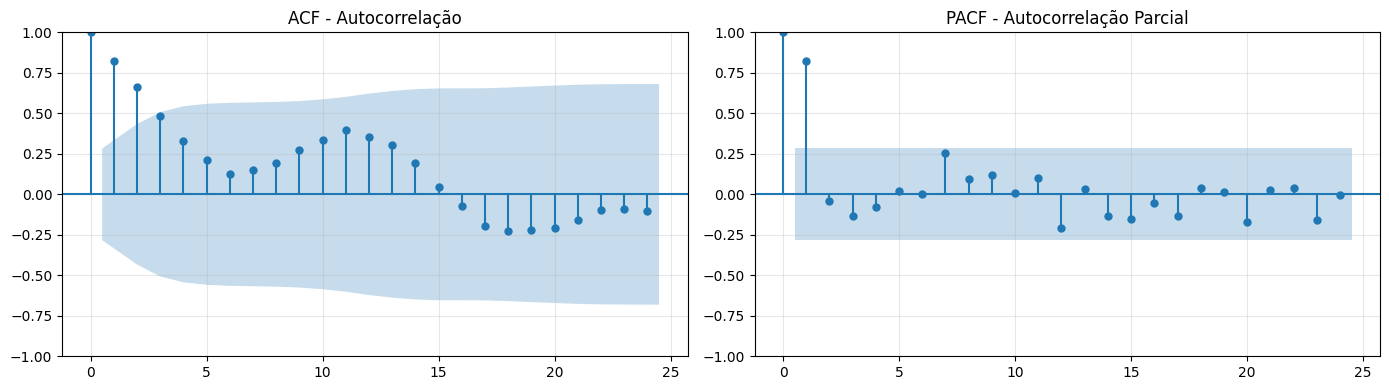

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(df['vendas'], lags=24, ax=axes[0], title='ACF - Autocorrelação')
plot_pacf(df['vendas'], lags=24, ax=axes[1], title='PACF - Autocorrelação Parcial')

plt.tight_layout()
plt.show()

###  ACF e PACF
- ACF apresenta decaimento lento → presença de tendência  
- PACF mostra corte inicial → possível componente AR  

### 📌 Interpretação
A série requer **diferenciação** para se tornar estacionária, sendo adequada para modelos como **ARIMA/SARIMA**.

# 4. Divisão Treino / Teste

Treino: Jan/2021 a Dec/2023
Teste: Jan/2024 a Dec/2024


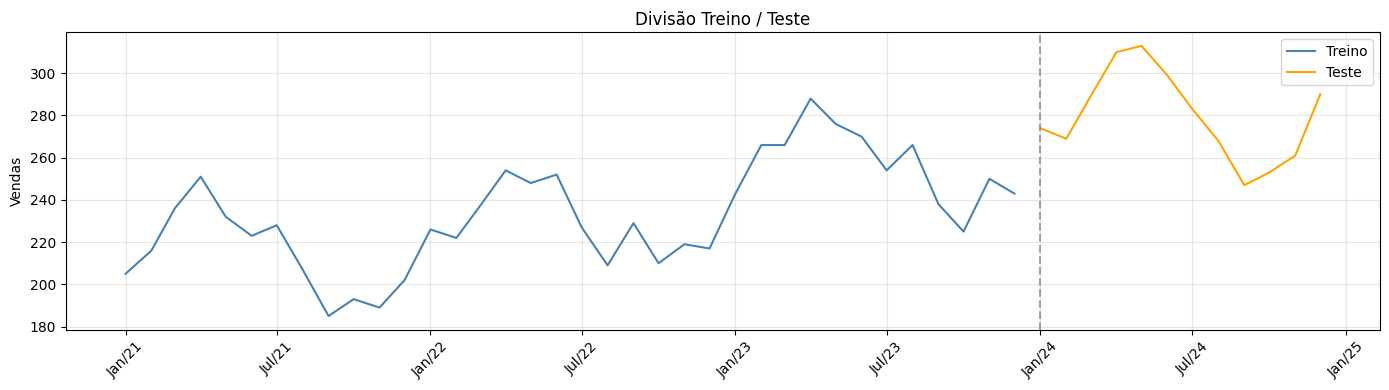

In [ ]:
treino = df.iloc[:36].copy()
teste = df.iloc[36:].copy()

print(f'Treino: {treino.index.min().strftime("%b/%Y")} a {treino.index.max().strftime("%b/%Y")}')
print(f'Teste: {teste.index.min().strftime("%b/%Y")} a {teste.index.max().strftime("%b/%Y")}')

fig, ax = plt.subplots()
ax.plot(treino.index, treino['vendas'], label='Treino', color='steelblue', linewidth=1.5)
ax.plot(teste.index, teste['vendas'], label='Teste', color='orange', linewidth=1.5)
ax.axvline(teste.index[0], color='gray', linestyle='--', alpha=0.7)
ax.set_title('Divisão Treino / Teste')
ax.set_ylabel('Vendas')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


A série foi dividida em:

- **Treino:** Jan/2021 a Dez/2023  
- **Teste:** Jan/2024 a Dez/2024  

### 📌 Interpretação
A separação respeita a ordem temporal, utilizando dados passados para treinar o modelo e dados futuros para avaliação.

Essa abordagem permite validar o desempenho preditivo em um cenário mais próximo da realidade.

# 5. Funções de Métricas e Plotagem dos gráficos com Previsões

In [ ]:
from sklearn import metrics

def calcula_metricas(real, previsto, nome_modelo):
  mae = metrics.mean_absolute_error(real, previsto)
  mse = metrics.mean_squared_error(real, previsto)
  rmse = np.sqrt(mse)
  mape = np.mean(np.abs((real - previsto) / real)) * 100

  print(f'{nome_modelo} | MAE: {mae:.2f} | MSE: {mse:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%')
  return {'Modelo': nome_modelo, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

In [ ]:
resultados = []
def plot_previsao(treino, teste, modelo, nome_modelo=''):

  previsoes = modelo.predict(len(treino), len(treino) + len(teste)-1)

  plt.figure(figsize=(12, 5))

  plt.plot(treino.index, treino['vendas'], label='Treino', color='steelblue', linewidth=1.5)
  plt.plot(teste.index, teste['vendas'], label='Teste', color='orange', linewidth=1.5)
  plt.plot(previsoes.index, previsoes, label='Previsão', color='green', linestyle='--', linewidth=1.5)

  plt.axvline(teste.index[0], color='gray', linestyle='--', alpha=0.7)

  plt.title(f'Previsão de Vendas - {nome_modelo}')
  plt.ylabel('Vendas')
  plt.legend()
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

  resultados.append(calcula_metricas(teste['vendas'], previsoes, nome_modelo))

In [ ]:
def plot_previsao_ml(treino, teste, previsoes, nome_modelo=""):

    plt.figure(figsize=(12, 5))

    plt.plot(treino.index, treino['vendas'], label='Treino', color='steelblue', linewidth=1.5)
    plt.plot(teste.index, teste['vendas'], label='Teste', color='orange', linewidth=1.5)
    plt.plot(teste.index, previsoes, label='Previsão', color='green', linestyle='--', linewidth=1.5)

    plt.axvline(teste.index[0], color='gray', linestyle='--', alpha=0.7)

    plt.title(f'Previsão de Vendas - {nome_modelo}')
    plt.ylabel('Vendas')
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    resultados.append(calcula_metricas(teste['vendas'], previsoes, nome_modelo))

# 6. Modelos de Previsão

## Modelo 1 - Holt-Winters (Suavização Exponencial Tripla)

Intuição: "Vamos suavizar a tendência E a sazonalidade ao mesmo tempo."
O Holt-Winters é uma evolução do SES que mantém três equações de suavização:
1. Nivel - onde a série está agora
2. Tendência - para onde está indo
3. Sazonalidade - padrão repetitivo

É um dos modelos mais usados na prática por ser simples e eficaz.

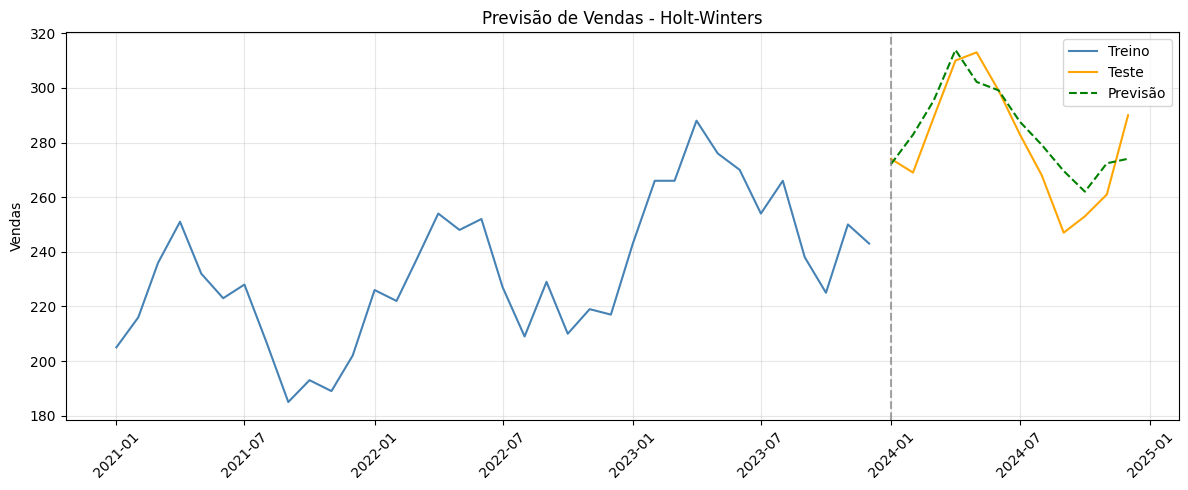

Holt-Winters | MAE: 9.29 | MSE: 123.96 | RMSE: 11.13 | MAPE: 3.42%


In [ ]:
modelo_hw = ExponentialSmoothing(
    treino['vendas'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

plot_previsao(treino, teste, modelo_hw, 'Holt-Winters')

### 📌 Características:
- Considera **nível, tendência e sazonalidade**  
- Utiliza suavização exponencial  
- Adequado para séries com padrão sazonal bem definido  

### 📊 Resultado
- **MAE:** 9.29  
- **RMSE:** 11.13  
- **MAPE:** 3.42%  

### 📌 Interpretação
O modelo apresentou **baixo erro e boa aderência aos dados reais**, sendo eficaz para capturar o comportamento da série.

## Modelo 2 – ARIMA (1,1,0)

O modelo ARIMA foi aplicado para capturar a **estrutura temporal** da série após diferenciação.


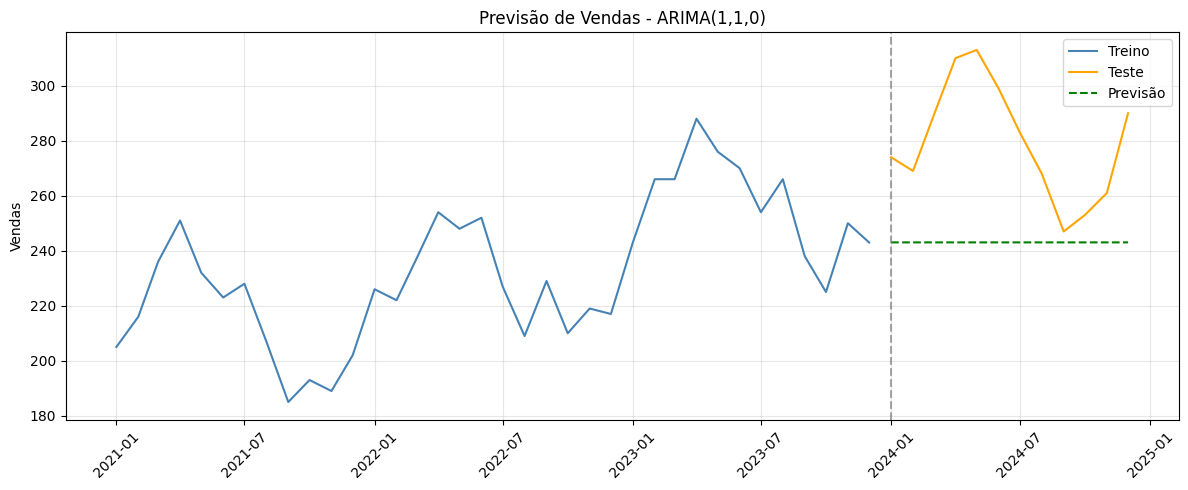

ARIMA(1,1,0) | MAE: 36.63 | MSE: 1759.97 | RMSE: 41.95 | MAPE: 12.63%


In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

modelo_arima = ARIMA(treino['vendas'], order=(1, 1, 0)).fit()

plot_previsao(treino, teste, modelo_arima, 'ARIMA(1,1,0)')


### 📌 Características:
- Considera dependência temporal (autoregressão)  
- Utiliza diferenciação (d=1) para remover tendência  
- Não modela sazonalidade explicitamente  

### 📊 Resultado
- **MAE:** 36.63  
- **RMSE:** 41.95  
- **MAPE:** 12.63%  

### 📌 Interpretação
O modelo apresentou **desempenho inferior**, com previsões pouco responsivas às variações da série.

Isso ocorre porque o ARIMA não captura a **sazonalidade presente nos dados**, resultando em previsões mais estáticas.

##  Modelo 3 – SARIMA (1,1,0)(1,1,0,12)

O modelo SARIMA foi aplicado para capturar **tendência e sazonalidade** da série.

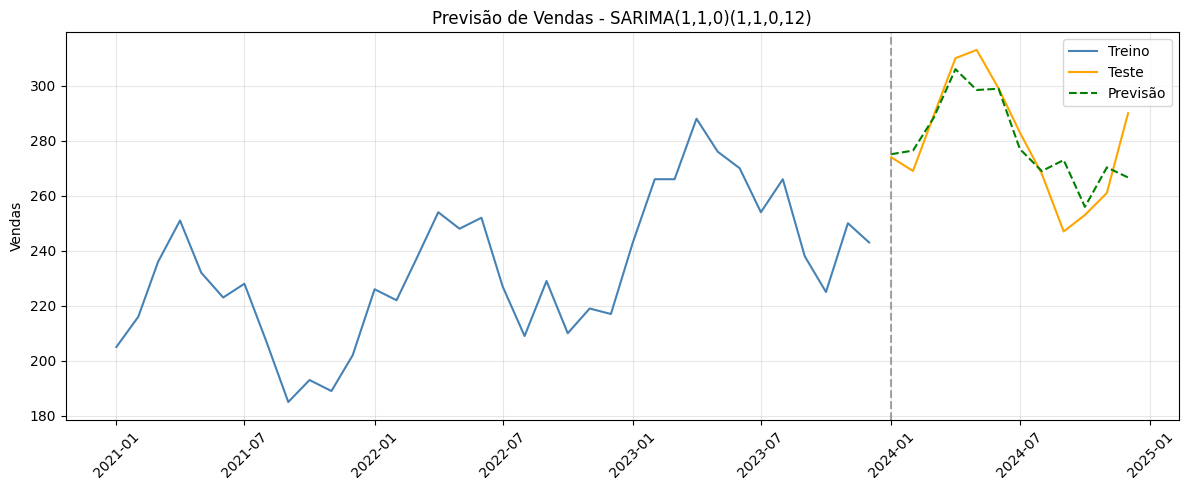

SARIMA(1,1,0)(1,1,0,12) | MAE: 8.04 | MSE: 136.46 | RMSE: 11.68 | MAPE: 2.93%


In [ ]:
modelo_sarima = SARIMAX(
    treino['vendas'],
    order=(1, 1, 0),
    seasonal_order=(1, 1, 0, 12)
).fit()

plot_previsao(treino, teste, modelo_sarima, 'SARIMA(1,1,0)(1,1,0,12)')

### 📌 Características:
- Extensão do ARIMA com componente sazonal  
- Considera dependência temporal e padrão anual  
- Adequado para séries com sazonalidade definida  

### 📊 Resultado
- **MAE:** 8.04  
- **RMSE:** 11.68  
- **MAPE:** 2.93%  

### 📌 Interpretação
O modelo apresentou o **melhor desempenho entre os testados**, com previsões mais próximas dos valores reais.

Isso confirma que a inclusão da **sazonalidade** é essencial para modelar corretamente a série.

##  Modelo 4 – Random Forest

O modelo Random Forest foi aplicado utilizando **features derivadas da série**, como defasagens (lags), médias móveis e variáveis de tempo.


In [ ]:
df_ml = df.copy()

df_ml['lag_1'] = df_ml['vendas'].shift(1)
df_ml['lag_2'] = df_ml['vendas'].shift(2)
df_ml['lag_3'] = df_ml['vendas'].shift(3)

In [ ]:
df_ml['mes'] = df_ml.index.month
df_ml['ano'] = df_ml.index.year

df_ml['media_3'] = df_ml['vendas'].shift(1).rolling(3).mean()
df_ml['media_6'] = df_ml['vendas'].shift(1).rolling(6).mean()
df_ml = df_ml.dropna()

In [ ]:
treino_ml = df_ml.iloc[:30].copy()
teste_ml = df_ml.iloc[30:].copy()

X_train = treino_ml.drop('vendas', axis=1)
y_train = treino_ml['vendas']

X_test = teste_ml.drop('vendas', axis=1)
y_test = teste_ml['vendas']

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)


RandomForestRegressor()

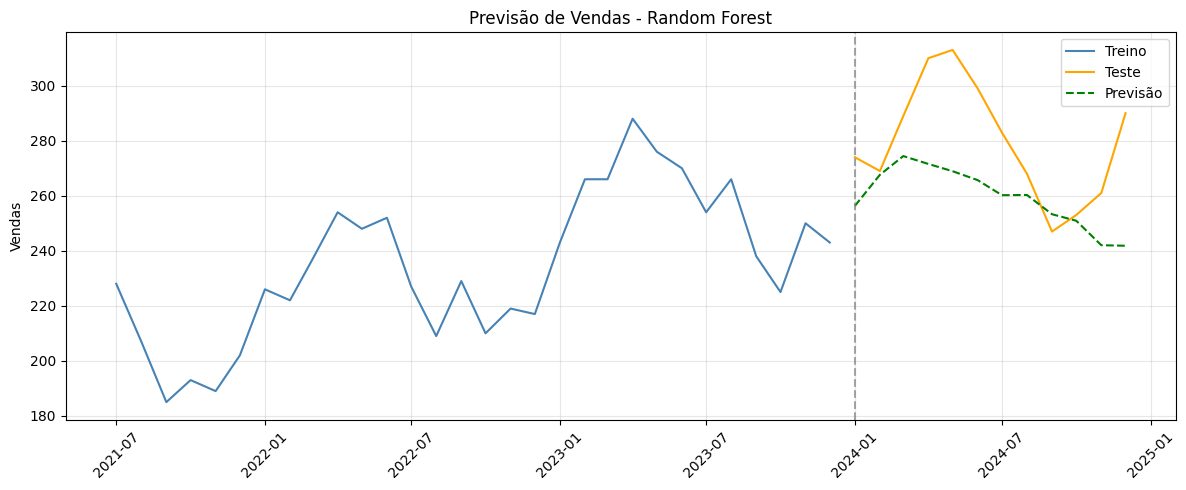

Random Forest | MAE: 21.29 | MSE: 696.80 | RMSE: 26.40 | MAPE: 7.32%


In [ ]:
y_pred_rf = model_rf.predict(X_test)

plot_previsao_ml(treino_ml, teste_ml, y_pred_rf, "Random Forest")

### 📌 Características:
- Modelo baseado em árvores (não linear)  
- Utiliza engenharia de features para capturar padrões  
- Não depende de suposições estatísticas da série  

### 📊 Resultado
- **MAE:** 21.29  
- **RMSE:** 26.40  
- **MAPE:** 7.32%  

### 📌 Interpretação
O modelo apresentou desempenho intermediário, capturando parte dos padrões, mas com menor precisão em relação aos modelos estatísticos.

Isso indica que, para este tipo de série com **sazonalidade bem definida**, modelos clássicos como SARIMA são mais adequados.

## Modelo 5 – Regressão Linear

O modelo de regressão linear foi aplicado utilizando **features derivadas da série**, como lags, médias móveis e variáveis temporais.


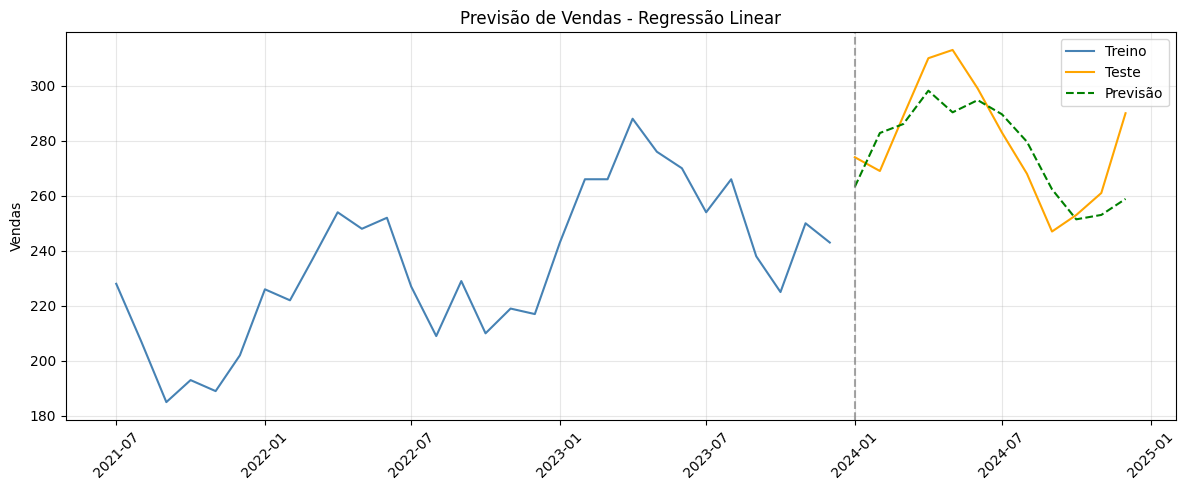

Regressão Linear | MAE: 11.71 | MSE: 203.05 | RMSE: 14.25 | MAPE: 4.15%


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_lr = LinearRegression()
model_lr.fit(X_train_scaled, y_train)

y_pred_lr = model_lr.predict(X_test_scaled)

# ajuste importante
y_pred_lr = pd.Series(y_pred_lr, index=teste_ml.index)

plot_previsao_ml(treino_ml, teste_ml, y_pred_lr, "Regressão Linear")

### 📌 Características:
- Modelo simples e interpretável  
- Assume relação linear entre variáveis  
- Depende da qualidade das features criadas  

### 📊 Resultado
- **MAE:** 11.71  
- **RMSE:** 14.25  
- **MAPE:** 4.15%  

### 📌 Interpretação
O modelo apresentou bom desempenho, sendo capaz de capturar parte da tendência e sazonalidade através das variáveis explicativas.

Apesar disso, não supera o SARIMA, que modela diretamente a estrutura temporal da série.

# 7. Resultados


A comparação dos modelos foi realizada com base nas métricas MAE, RMSE e MAPE.


In [ ]:
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = df_resultados.sort_values('MAE').round(2)

print('==== Comparação de Métricas (ordenado pelo MAE) ====')
print(df_resultados.to_string())

==== Comparação de Métricas (ordenado pelo MAE) ====
                           MAE      MSE   RMSE   MAPE
Modelo                                               
SARIMA(1,1,0)(1,1,0,12)   8.04   136.46  11.68   2.93
Holt-Winters              9.29   123.96  11.13   3.42
Regressão Linear         11.71   203.05  14.25   4.15
Random Forest            21.29   696.80  26.40   7.32
ARIMA(1,1,0)             36.63  1759.97  41.95  12.63


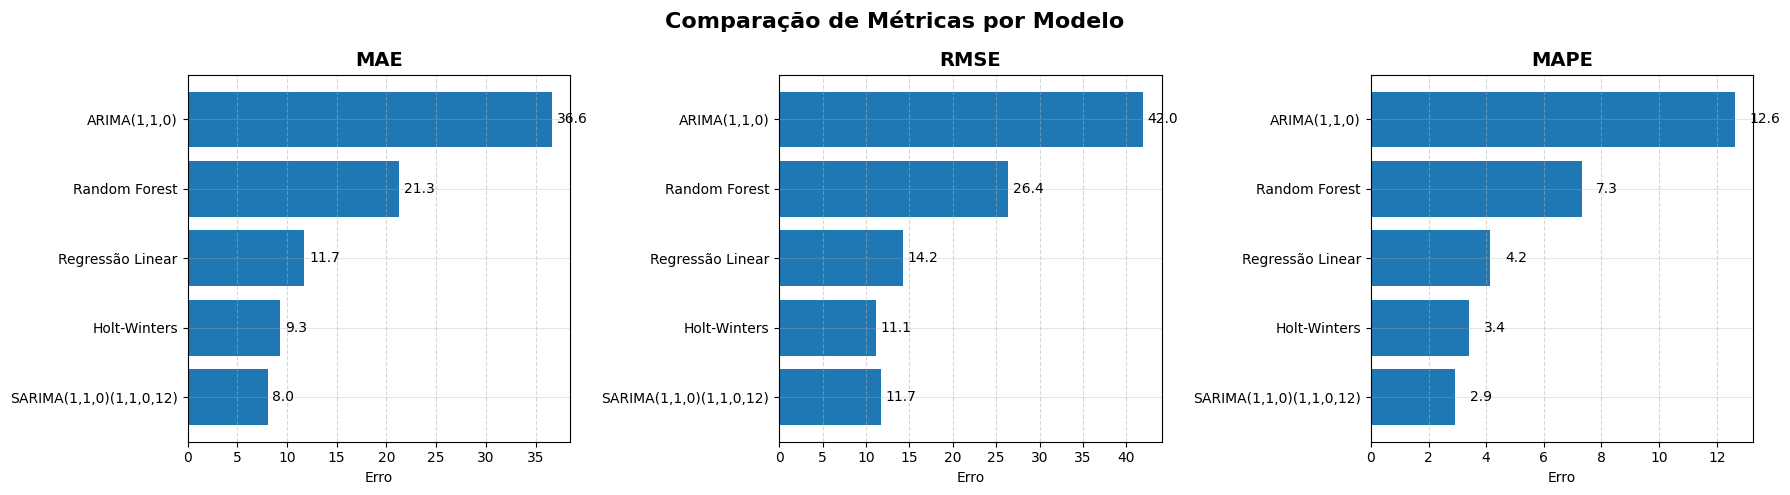

In [ ]:
df_plot = df_resultados.sort_values("MAE")

metricas = ["MAE", "RMSE", "MAPE"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metrica in enumerate(metricas):
    ax = axes[i]

    bars = ax.barh(df_plot.index, df_plot[metrica])

    ax.set_title(metrica, fontsize=14, fontweight='bold')
    ax.set_xlabel("Erro")

    # Adiciona valores nas barras
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                f"{width:.1f}", va='center')

    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.suptitle("Comparação de Métricas por Modelo", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Interpretação
O modelo **SARIMA** apresentou os menores erros em todas as métricas, sendo o mais adequado para a série analisada.

Isso confirma que a combinação de **tendência + sazonalidade** é essencial para modelar corretamente os dados.

Modelos que não capturam sazonalidade (ARIMA) ou dependem de features (ML) tiveram desempenho inferior.

# Previsão Final – Modelo SARIMA

Com base nos resultados obtidos, o modelo **SARIMA (1,1,0)(1,1,0,12)** foi selecionado como o mais adequado para a série.


In [ ]:
modelo_sarima = SARIMAX(
    treino['vendas'],
    order=(1, 1, 0),
    seasonal_order=(1, 1, 0, 12)
).fit()

previsao_vendas = modelo_sarima.predict(len(df), len(df) + 12)

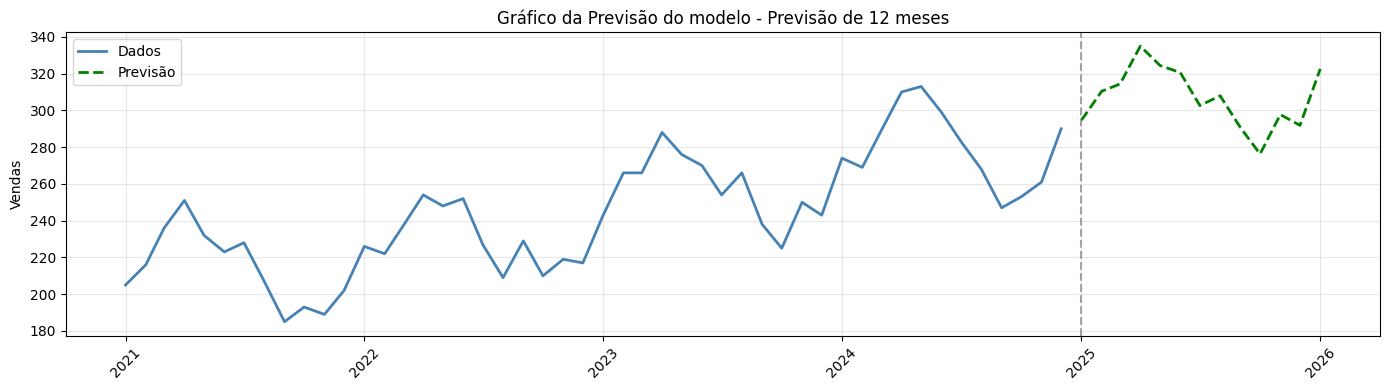

In [ ]:
plt.plot(df.index, df['vendas'], label='Dados', color='steelblue', linewidth=2)
plt.plot(previsao_vendas.index, previsao_vendas.values, label='Previsão', color='green', linestyle='--', linewidth=2)

plt.axvline(previsao_vendas.index[0], color='gray', linestyle='--', alpha=0.7)

plt.title('Gráfico da Previsão do modelo - Previsão de 12 meses')
plt.ylabel('Vendas')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###  Previsão
Foram geradas previsões para os **próximos 12 meses**, mantendo o padrão de:

- 📈 Tendência de crescimento  
- 🔄 Sazonalidade anual  

### 📌 Interpretação
As previsões indicam continuidade do comportamento histórico, com oscilações sazonais e crescimento moderado ao longo do tempo.
